# Lab 03: Pitch Classification

---
author: Trishla Nair
date: September 20, 2024
embed-resources: true
---

## Introduction

My objective is to create a classification model that predicts the pitch type of a pitch thrown by a particular pitcher given the pitch’s velocity, rotation, movement, and batter's position. The data is frrom Statcast.

## Methods

In [24]:
# imports
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from joblib import dump

### Data

In [25]:
# load data
pitches_train = pd.read_parquet(
    "https://cs307.org/lab-03/data/pitches-train.parquet"
)
pitches_test = pd.read_parquet(
    "https://cs307.org/lab-03/data/pitches-test.parquet"
)

In [26]:
pitches_train

,pitch_name,release_speed,release_spin_rate,pfx_x,pfx_z,stand
0,Sweeper,84.7,2667.0,1.25,0.01,R
1,Sweeper,83.9,2634.0,1.41,0.20,R
2,Sweeper,84.4,2526.0,1.26,0.25,R
3,Curveball,74.3,2389.0,0.93,-1.10,L
4,Sweeper,85.6,2474.0,1.08,0.52,R
...,...,...,...,...,...,...
2623,Split-Finger,91.8,1314.0,-0.30,0.08,R
2624,Sweeper,86.9,2440.0,1.11,0.51,R
2625,4-Seam Fastball,99.2,2320.0,0.04,0.81,R
2626,4-Seam Fastball,97.9,2164.0,0.08,1.06,R


The response variable is the pitch name. The data set contains multiple missing values. Using a imputer for numerical data and one hot encoding for categorical data, we will fill in the missing values.

In [27]:
# summary statistics
vel_by_type = pitches_train.groupby("pitch_name")["release_speed"].agg(["count","mean", "std"]).reset_index()
vel_by_type

,pitch_name,count,mean,std
0,4-Seam Fastball,718,97.270613,1.699270
1,Curveball,222,77.679730,3.215206
2,Cutter,233,90.742060,2.364489
3,Sinker,97,97.160825,1.829592
4,Slider,63,85.203175,2.401543
5,Split-Finger,312,89.291346,1.759299
6,Sweeper,983,85.336419,1.862552


In [28]:
# summary statistics
spin_by_type = pitches_train.groupby("pitch_name")["release_spin_rate"].agg(["count","mean", "std"]).reset_index()
spin_by_type

,pitch_name,count,mean,std
0,4-Seam Fastball,714,2217.331933,114.754683
1,Curveball,222,2482.666667,119.854726
2,Cutter,233,2378.424893,206.685887
3,Sinker,95,1972.747368,143.920632
4,Slider,63,2497.619048,78.679306
5,Split-Finger,312,1273.560897,221.291146
6,Sweeper,983,2492.172940,103.176892


In [29]:
pitches_train.isna().sum()

pitch_name           0
release_speed        0
release_spin_rate    6
pfx_x                0
pfx_z                0
stand                0
dtype: int64

In [30]:
#pipeline
# note numeric and categorical features
categorical_features = pitches_train.select_dtypes(include="object").columns
numeric_features = pitches_train.select_dtypes(exclude="object").columns

# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
preprocessor.fit(pitches_train)

pitch_train = pd.DataFrame(
    preprocessor.transform(pitches_train),
    columns=preprocessor.get_feature_names_out(),
)

In [31]:
pitch_train

,num__release_speed,num__release_spin_rate,num__pfx_x,num__pfx_z,cat__pitch_name_Curveball,cat__pitch_name_Cutter,cat__pitch_name_Sinker,cat__pitch_name_Slider,cat__pitch_name_Split-Finger,cat__pitch_name_Sweeper,cat__stand_R
0,-0.718383,1.044933,1.104590,-0.687166,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,-0.842450,0.963659,1.306321,-0.401003,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.764908,0.697671,1.117198,-0.325696,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,-2.331254,0.360260,0.701129,-2.358964,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.578808,0.569603,0.890252,0.080957,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2623,0.382711,-2.287306,-0.849673,-0.581737,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2624,-0.377199,0.485866,0.928076,0.065896,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2625,1.530330,0.190323,-0.420996,0.517733,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2626,1.328721,-0.193882,-0.370564,0.894264,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Text(0, 0.5, 'Average release speed')

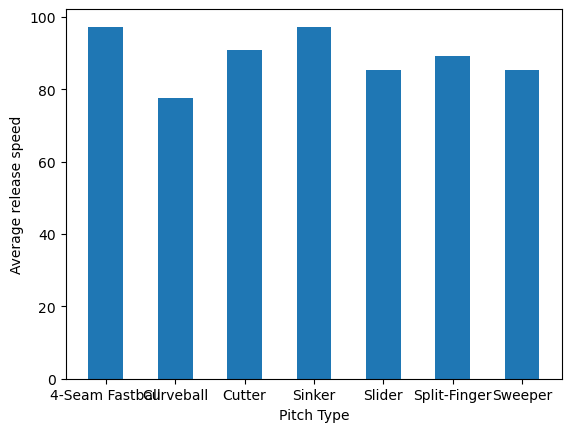

In [32]:
# visualizations
speed_and_spin = pitches_train.groupby("pitch_name")[["release_speed", "release_spin_rate"]].agg("mean").reset_index()
plt.bar(speed_and_spin['pitch_name'], speed_and_spin['release_speed'], width = 0.5)
plt.xlabel("Pitch Type")
plt.ylabel("Average release speed")

Text(0, 0.5, 'Average release spin rate')

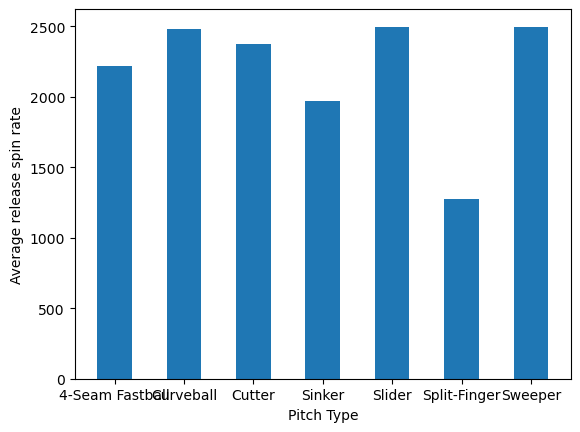

In [33]:
plt.bar(speed_and_spin['pitch_name'], speed_and_spin['release_spin_rate'], width = 0.5)
plt.xlabel("Pitch Type")
plt.ylabel("Average release spin rate")

The 2 bargraphs depict the average spin rate and the average speed per pitch type. When the ball is thrown as a split-finger, it spins less however it has 1 of the highest release speeds. Intrestingly, on average curve balls have the slowest average speed but the higheest spin rate. This suggests an inverse correlation between speed and spin.

### Models

In [34]:
# process data for ML
# create X and y for train
X_train = pitches_train.drop("pitch_name", axis=1)
y_train = pitches_train["pitch_name"]

# create X and y for test
X_test = pitches_test.drop("pitch_name", axis=1)
y_test = pitches_test["pitch_name"]

In [53]:
# train models
numeric_features = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z']
categorical_features = ['stand']

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
    ]
)
categorical_features = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)
# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier()),
    ]
)

param_grid = {
    "classifier__n_neighbors":[1, len(pitches_train), 6],
    "classifier__metric":['euclidean','manhattan'],
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring ='accuracy')
mod = grid_search.fit(X_train, y_train)

ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\pipeline.py", line 469, in fit
    Xt = self._fit(X, y, routed_params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\pipeline.py",

When trying to use this model, it seems an error is generated. Yet somehow, the model functions.

## Results

In [55]:
# report model metrics
dump(mod, "pitch-classifier.joblib")

['pitch-classifier.joblib']

## Discussion

It's difficult to determine how effecttive the model is and how the batter's position affects the pitch type.

### Conclusion

Basesd on the model and it's failure, this model might not be completely great for this dataset.